In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

# -----------------------------
# Data Augmentation
# -----------------------------
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    transforms.RandomErasing(p=0.2)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

# -----------------------------
# ADMM Layers
# -----------------------------
class ADMMConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, rho=1e-4):
        super(ADMMConv2d, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=True)
        self.rho = rho
        self.register_buffer("Z", torch.zeros_like(self.conv.weight))
        self.register_buffer("U", torch.zeros_like(self.conv.weight))

    def forward(self, x):
        return self.conv(x)

    def admm_loss(self):
        return (self.rho / 2) * torch.norm(self.conv.weight - self.Z + self.U) ** 2

    def update_ZU(self):
        with torch.no_grad():
            temp = self.conv.weight + self.U
            threshold = self.rho
            self.Z = torch.sign(temp) * torch.clamp(torch.abs(temp) - threshold, min=0)
            self.U = self.U + (self.conv.weight - self.Z)


class ADMMLinear(nn.Module):
    def __init__(self, in_features, out_features, rho=1e-4):
        super(ADMMLinear, self).__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.rho = rho
        self.register_buffer("Z", torch.zeros_like(self.fc.weight))
        self.register_buffer("U", torch.zeros_like(self.fc.weight))

    def forward(self, x):
        return self.fc(x)

    def admm_loss(self):
        return (self.rho / 2) * torch.norm(self.fc.weight - self.Z + self.U) ** 2

    def update_ZU(self):
        with torch.no_grad():
            temp = self.fc.weight + self.U
            threshold = self.rho
            self.Z = torch.sign(temp) * torch.clamp(torch.abs(temp) - threshold, min=0)
            self.U = self.U + (self.fc.weight - self.Z)


# -----------------------------
# CNN with ADMM
# -----------------------------
class CNN_ADMM(nn.Module):
    def __init__(self, rho=1e-4):
        super(CNN_ADMM, self).__init__()
        self.conv = nn.Sequential(
            ADMMConv2d(3, 64, 3, padding=1, rho=rho), nn.BatchNorm2d(64), nn.ReLU(),
            ADMMConv2d(64, 64, 3, padding=1, rho=rho), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16x16

            ADMMConv2d(64, 128, 3, padding=1, rho=rho), nn.BatchNorm2d(128), nn.ReLU(),
            ADMMConv2d(128, 128, 3, padding=1, rho=rho), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 8x8

            ADMMConv2d(128, 256, 3, padding=1, rho=rho), nn.BatchNorm2d(256), nn.ReLU(),
            ADMMConv2d(256, 256, 3, padding=1, rho=rho), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 4x4
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            ADMMLinear(256 * 4 * 4, 512, rho=rho), nn.ReLU(), nn.Dropout(0.4),
            ADMMLinear(512, 10, rho=rho)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

    def admm_loss(self):
        penalty = 0
        for module in self.modules():
            if isinstance(module, (ADMMConv2d, ADMMLinear)):
                penalty += module.admm_loss()
        return penalty

    def update_ZU(self):
        for module in self.modules():
            if isinstance(module, (ADMMConv2d, ADMMLinear)):
                module.update_ZU()


# -----------------------------
# Setup
# -----------------------------
model = CNN_ADMM(rho=1e-4).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=70)

# -----------------------------
# ADMM Pruning Phase
# -----------------------------
print("ADMM pruning phase...")
for epoch in range(50):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels) + model.admm_loss()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Update Z and U
    model.update_ZU()
    scheduler.step()
    print(f"ADMM Epoch [{epoch+1}/50] Loss: {total_loss/len(train_loader):.4f}")

# -----------------------------
# Evaluation
# -----------------------------
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = 100 * correct / total
print(f"Final Accuracy after ADMM pruning + fine-tuning: {acc:.2f}%")


# Save model
torch.save(model.state_dict(), 'cnn_admm_pruned_improved.pth')


Running on: cuda
ADMM pruning phase...
ADMM Epoch [1/50] Loss: 1.8818
ADMM Epoch [2/50] Loss: 1.5124
ADMM Epoch [3/50] Loss: 1.3511
ADMM Epoch [4/50] Loss: 1.2576
ADMM Epoch [5/50] Loss: 1.1831
ADMM Epoch [6/50] Loss: 1.1221
ADMM Epoch [7/50] Loss: 1.0775
ADMM Epoch [8/50] Loss: 1.0437
ADMM Epoch [9/50] Loss: 1.0065
ADMM Epoch [10/50] Loss: 0.9825
ADMM Epoch [11/50] Loss: 0.9623
ADMM Epoch [12/50] Loss: 0.9413
ADMM Epoch [13/50] Loss: 0.9209
ADMM Epoch [14/50] Loss: 0.9022
ADMM Epoch [15/50] Loss: 0.8833
ADMM Epoch [16/50] Loss: 0.8689
ADMM Epoch [17/50] Loss: 0.8514
ADMM Epoch [18/50] Loss: 0.8400
ADMM Epoch [19/50] Loss: 0.8311
ADMM Epoch [20/50] Loss: 0.8185
ADMM Epoch [21/50] Loss: 0.8094
ADMM Epoch [22/50] Loss: 0.7947
ADMM Epoch [23/50] Loss: 0.7835
ADMM Epoch [24/50] Loss: 0.7761
ADMM Epoch [25/50] Loss: 0.7674
ADMM Epoch [26/50] Loss: 0.7585
ADMM Epoch [27/50] Loss: 0.7447
ADMM Epoch [28/50] Loss: 0.7463
ADMM Epoch [29/50] Loss: 0.7324
ADMM Epoch [30/50] Loss: 0.7286
ADMM Epoch


Classification Report:

              precision    recall  f1-score   support

    airplane     0.9200    0.9200    0.9200      1000
  automobile     0.9619    0.9590    0.9604      1000
        bird     0.8765    0.8940    0.8851      1000
         cat     0.8494    0.8180    0.8334      1000
        deer     0.8808    0.9380    0.9085      1000
         dog     0.8756    0.8450    0.8601      1000
        frog     0.9326    0.9540    0.9432      1000
       horse     0.9585    0.9240    0.9409      1000
        ship     0.9455    0.9540    0.9497      1000
       truck     0.9537    0.9480    0.9509      1000

    accuracy                         0.9154     10000
   macro avg     0.9154    0.9154    0.9152     10000
weighted avg     0.9154    0.9154    0.9152     10000



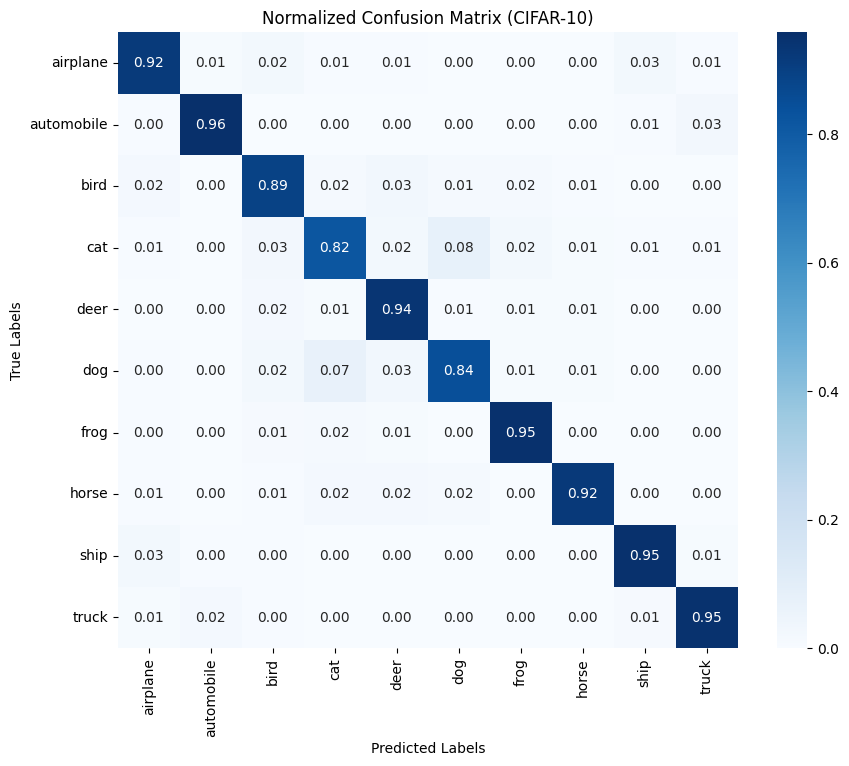

In [3]:
# -----------------------------
# Classification Report & Confusion Matrix
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class names
classes = ('airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# Print classification report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, cmap='Blues', fmt='.2f',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Normalized Confusion Matrix (CIFAR-10)')
plt.show()
